In [ ]:
#!/usr/bin/env python3
"""
Jupyter notebook version of training configuration runner with real-time output
"""

import os
import sys
import subprocess
import glob
import platform
import shutil
from pathlib import Path
from IPython.display import display, clear_output
import time
import threading
from queue import Queue, Empty

os.environ['PYTHONUNBUFFERED'] = '1'
os.environ['PYTHON_EXECUTABLE'] = sys.executable


class JupyterTrainingRunner:
    def __init__(self):
        self.script_dir = self.get_script_directory()
        self.original_dir = os.getcwd()
        
    def get_script_directory(self):
        """Get the directory where this script is located"""
        return Path(r"c:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim").absolute()
        if '__file__' in globals():
            return Path(__file__).parent.absolute()
        else:
            return Path.cwd()
    
    def list_available_configs(self):
        """List all available configuration files"""
        config_dir = self.script_dir / "optim" / "training_configs"
        
        if not config_dir.exists():
            print(f"  No training_configs directory found at: {config_dir}")
            return []
        
        config_files = []
        for ext in ["*.bat", "*.sh"]:
            config_files.extend(glob.glob(str(config_dir / ext)))
        
        if not config_files:
            print("  No configuration files found")
            return []
        
        config_names = []
        for config_file in config_files:
            name = Path(config_file).stem
            if name not in config_names:
                config_names.append(name)
        
        return sorted(config_names)
    
    def setup_environment(self):
        os.chdir(self.script_dir.parent)
        
        root_dir = Path(os.getcwd()) / "ctrl_optim"
        
        current_pythonpath = os.environ.get('PYTHONPATH', '')
        new_pythonpath = f"{root_dir}{os.pathsep}{current_pythonpath}" if current_pythonpath else str(root_dir)
        
        os.environ['PYTHONPATH'] = new_pythonpath
        os.environ['ROOT_DIR'] = str(root_dir)
        os.environ['PYTHONUNBUFFERED'] = '1'
        
        os.chdir(root_dir)
        

    
    def read_output_stream(self, stream, queue):
        try:
            for line in iter(stream.readline, ''):
                if line:
                    queue.put(line.rstrip())
            queue.put(None)  # end
        except Exception as e:
            queue.put(f"Error reading stream: {e}")
            queue.put(None)
    
    def run_training_with_realtime_output(self, config_name, update_interval=0.1):
        config_dir = self.script_dir / "optim" / "training_configs"
        
        is_windows = platform.system() == "Windows"
        
        if is_windows:
            primary_config = config_dir / f"{config_name}.bat"
            fallback_config = config_dir / f"{config_name}.sh"
        else:
            primary_config = config_dir / f"{config_name}.sh"
            fallback_config = config_dir / f"{config_name}.bat"
        
        config_file = None
        if primary_config.exists():
            config_file = primary_config
        elif fallback_config.exists():
            print(f"Warning: Preferred script type for your OS ({primary_config.suffix}) not found.")
            print(f"Attempting to use {fallback_config.suffix} script instead.")
            config_file = fallback_config
        
        if not config_file:
            print(f"Error: Configuration '{config_name}' not found")
            print()
            print("Available configurations:")
            for config in self.list_available_configs():
                print(f"  {config}")
            return False
        
        optim_dir = self.script_dir / "optim"
        os.chdir(optim_dir)
        print(f"Changed to optim directory: {optim_dir}")
        
        try:
            if platform.system() == "Windows":
                if config_file.suffix == ".bat":
                    cmd = ["cmd", "/c", str(config_file)]
                else:
                    if not shutil.which('bash'):
                        print("Error: bash is required to run .sh files on Windows")
                        return False
                    cmd = ["bash", str(config_file)]
            else:
                if config_file.suffix == ".sh":
                    os.chmod(config_file, 0o755)
                    cmd = ["bash", str(config_file)]
                else:
                    print("Error: .bat files are not supported on Unix-like systems")
                    return False
            
            print(f"Starting training with configuration: {config_name}")
            print(f"Command: {' '.join(cmd)}")
            print("=" * 60)
            
            process = subprocess.Popen(
                cmd,
                stdout=subprocess.PIPE,
                stderr=subprocess.STDOUT,
                universal_newlines=True,
                bufsize=1,
                env=os.environ.copy()
            )
            
            output_queue = Queue()
            
            output_thread = threading.Thread(
                target=self.read_output_stream,
                args=(process.stdout, output_queue)
            )
            output_thread.daemon = True
            output_thread.start()
            
            output_lines = []
            last_update = time.time()
            
            while True:
                try:
                    line = output_queue.get(timeout=update_interval)
                    
                    if line is None:  # End 
                        break
                    
                    output_lines.append(line)
                    
                    current_time = time.time()
                    if (current_time - last_update > update_interval or 
                        any(keyword in line.lower() for keyword in 
                            ['error', 'iteration', 'epoch', 'generation', 'best', 'completed'])):
                        
                        clear_output(wait=True)
                        print(f"Training: {config_name}")
                        print("=" * 60)
                        display_lines = output_lines[-50:] if len(output_lines) > 50 else output_lines
                        for display_line in display_lines:
                            print(display_line)
                        
                        if len(output_lines) > 50:
                            print(f"... ({len(output_lines) - 50} earlier lines hidden)")
                        
                        print(f"\nLines processed: {len(output_lines)}")
                        last_update = current_time
                        
                except Empty:
                    if process.poll() is not None:
                        break
                    continue
            
            process.wait()
            
            clear_output(wait=True)
            
            # Show final output
            display_lines = output_lines[-100:] if len(output_lines) > 100 else output_lines
            for line in display_lines:
                print(line)
            
            if len(output_lines) > 100:
                print(f"... ({len(output_lines) - 100} earlier lines hidden)")
            
            print("=" * 60)
            
            if process.returncode == 0:
                return True
            else:
                return False
                
        except Exception as e:
            return False
        finally:
            os.chdir(self.original_dir)
    
    def run_training_simple(self, config_name):
        config_dir = self.script_dir / "optim" / "training_configs"
        
        # Select script type based on OS
        is_windows = platform.system() == "Windows"
        
        if is_windows:
            config_file = config_dir / f"{config_name}.bat"
            if not config_file.exists():
                config_file = config_dir / f"{config_name}.sh"
        else:
            config_file = config_dir / f"{config_name}.sh"
            if not config_file.exists():
                config_file = config_dir / f"{config_name}.bat"
        
        if not config_file.exists():
            print(f"Error: Configuration '{config_name}' not found")
            return False
        
        optim_dir = self.script_dir / "optim"
        os.chdir(optim_dir)
        
        try:
            if platform.system() == "Windows":
                if config_file.suffix == ".bat":
                    result = subprocess.run(["cmd", "/c", str(config_file)], 
                                          shell=True, check=True, 
                                          capture_output=True, text=True,
                                          env=os.environ.copy())
                else:
                    result = subprocess.run(["bash", str(config_file)], 
                                          shell=True, check=True, 
                                          capture_output=True, text=True,
                                          env=os.environ.copy())
            else:
                os.chmod(config_file, 0o755)
                result = subprocess.run([str(config_file)], 
                                      shell=True, check=True, 
                                      capture_output=True, text=True,
                                      env=os.environ.copy())
            
            print(result.stdout)
            if result.stderr:
                print("Errors:")
                print(result.stderr)
            
            return True
            
        except subprocess.CalledProcessError as e:
            print(f"Error executing configuration: {e}")
            if e.stdout:
                print("Output:", e.stdout)
            if e.stderr:
                print("Error output:", e.stderr)
            return False
        finally:
            os.chdir(self.original_dir)


def run_training(config_name, realtime=True, update_interval=0.1):
    
    runner = JupyterTrainingRunner()
    runner.setup_environment()
    
    if realtime:
        return runner.run_training_with_realtime_output(config_name, update_interval)
    else:
        return runner.run_training_simple(config_name)


def list_configs():
    runner = JupyterTrainingRunner()
    configs = runner.list_available_configs()
    
    if configs:
        print("Available training configurations:")
        for i, config in enumerate(configs, 1):
            print(f"{i:2d}. {config}")
    else:
        print("No configurations found")
    
    return configs


In [ ]:
import os
run_training('baseline_hmedi', realtime = True)

Training: baseline_hmedi
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoSarcArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoFatiArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoArmReachRandom-v0 already in registry.
  logger.warn(f"Overriding environment {new_sp

In [2]:
import os
run_training('baseline_humo', realtime = True)

Training: baseline_humo
  744   2976 9.899148524167099e+04 1.5e+00 2.31e-03  2e-02  2e-02 19:03.3
  757   3028 9.899374023965691e+04 1.5e+00 2.15e-03  2e-02  2e-02 19:52.1
  768   3072 9.898961918625867e+04 1.5e+00 2.02e-03  2e-02  2e-02 20:45.8
  779   3116 9.898978445664210e+04 1.5e+00 1.90e-03  2e-02  2e-02 21:37.5
  789   3156 9.899021986795578e+04 1.5e+00 1.84e-03  2e-02  2e-02 22:30.9
  800   3200 9.899623902506506e+04 1.5e+00 1.86e-03  2e-02  2e-02 23:16.2
  813   3252 9.899248821623904e+04 1.6e+00 2.00e-03  2e-02  2e-02 24:09.3
  832   3328 9.899424860536950e+04 1.6e+00 2.01e-03  2e-02  2e-02 25:05.9
  852   3408 9.899183501291956e+04 1.6e+00 2.17e-03  2e-02  2e-02 26:02.7
  872   3488 9.899617544464287e+04 1.6e+00 2.30e-03  2e-02  2e-02 27:00.4
  888   3552 9.898976894911058e+04 1.6e+00 2.63e-03  3e-02  3e-02 28:01.2
  896   3584 9.898264998546545e+04 1.6e+00 2.80e-03  3e-02  3e-02 28:59.3
  904   3616 9.898483811679338e+04 1.6e+00 2.96e-03  3e-02  3e-02 30:02.7
  918   3672 9

True

In [9]:
import os
run_training('baseline_dephy', realtime = True)

  774   3096 1.786736218904728e+02 1.5e+00 2.12e-03  2e-02  2e-02 77:44.8
  783   3132 1.818250560038667e+02 1.5e+00 2.02e-03  2e-02  2e-02 79:22.5
  792   3168 1.821016155795423e+02 1.5e+00 1.92e-03  2e-02  2e-02 81:01.9
  800   3200 1.803564333864310e+02 1.5e+00 1.87e-03  2e-02  2e-02 82:29.6
  809   3236 1.007053108863568e+04 1.5e+00 1.82e-03  2e-02  2e-02 84:07.7
  818   3272 1.006763435702751e+04 1.5e+00 1.79e-03  2e-02  2e-02 85:47.0
  828   3312 1.801032611796464e+02 1.5e+00 1.72e-03  2e-02  2e-02 87:35.0
  838   3352 1.006803593755548e+04 1.5e+00 1.60e-03  2e-02  2e-02 89:21.3
  848   3392 1.811590893559669e+02 1.5e+00 1.55e-03  1e-02  2e-02 91:10.5
  858   3432 1.702934744254255e+02 1.5e+00 1.58e-03  1e-02  2e-02 92:58.7
  868   3472 1.742619056788416e+02 1.5e+00 1.65e-03  2e-02  2e-02 94:48.1
  878   3512 1.007385747252291e+04 1.5e+00 1.68e-03  2e-02  2e-02 96:36.9
  889   3556 9.897710427265496e+04 1.5e+00 1.63e-03  2e-02  2e-02 98:27.5
  899   3596 1.704910790139937e+02 1.5

True

In [23]:
import os
run_training('exo_dephy', realtime = True)

  186    744 9.899722663060162e+04 1.4e+00 7.64e-03  8e-02  8e-02 6:25.8
  193    772 9.795775991383199e+04 1.4e+00 7.51e-03  7e-02  8e-02 7:01.9
  200    800 9.899389231858341e+04 1.4e+00 7.22e-03  7e-02  7e-02 7:27.0
  206    824 9.898937345367872e+04 1.4e+00 7.18e-03  7e-02  7e-02 8:00.9
  209    836 1.009195941997281e+04 1.4e+00 7.21e-03  7e-02  7e-02 8:31.8
  220    880 9.899679481076173e+04 1.4e+00 7.63e-03  8e-02  8e-02 9:04.3
  242    968 9.899698990320916e+04 1.4e+00 7.95e-03  8e-02  8e-02 9:37.4
  251   1004 9.898188447178535e+04 1.4e+00 7.88e-03  8e-02  8e-02 10:16.4
  260   1040 9.898300699568554e+04 1.4e+00 7.58e-03  7e-02  8e-02 10:52.7
  270   1080 9.898573807096973e+04 1.4e+00 7.85e-03  8e-02  8e-02 11:30.8
  281   1124 9.899383523004130e+04 1.4e+00 8.09e-03  8e-02  8e-02 12:08.3
  290   1160 9.898584132476403e+04 1.4e+00 8.11e-03  8e-02  8e-02 12:45.9
  300   1200 1.009356951683613e+04 1.4e+00 7.68e-03  8e-02  8e-02 13:25.4
  309   1236 9.897939773626521e+04 1.4e+00 7.

True

In [56]:
import os
run_training('exo_tut', realtime = True)

c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoFatiArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoArmReachRandom-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoSarcArmReachRandom-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoFatiArmReachRandom-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in r

True

In [7]:
import os
run_training('baseline', realtime = True)

 2383   9532 9.899502145897032e+04 2.0e+00 4.69e-04  4e-03  5e-03 73:26.4
 2400   9600 9.899591995162649e+04 2.0e+00 4.12e-04  4e-03  5e-03 74:20.5
 2441   9764 9.899707069712869e+04 2.0e+00 4.28e-04  4e-03  5e-03 75:57.9
 2481   9924 9.899591573682360e+04 2.0e+00 3.97e-04  4e-03  4e-03 77:36.7
 2521  10084 9.899199861705092e+04 2.0e+00 3.38e-04  3e-03  4e-03 79:16.3
 2559  10236 9.899565274483249e+04 2.0e+00 2.71e-04  2e-03  3e-03 80:57.1
 2596  10384 9.899560224894535e+04 2.1e+00 2.87e-04  3e-03  3e-03 82:40.2
 2600  10400 9.899597593725052e+04 2.1e+00 2.93e-04  3e-03  3e-03 82:48.4
 2634  10536 9.899308707454331e+04 2.1e+00 3.26e-04  3e-03  4e-03 84:32.9
 2669  10676 9.899437807908874e+04 2.1e+00 2.94e-04  3e-03  3e-03 86:18.0
 2707  10828 9.899401845726943e+04 2.1e+00 2.40e-04  2e-03  3e-03 88:09.0
 2746  10984 9.899200964065213e+04 2.1e+00 2.37e-04  2e-03  3e-03 89:56.1
 2781  11124 9.899320751843006e+04 2.1e+00 2.21e-04  2e-03  2e-03 91:44.5
 2800  11200 9.899575638398720e+04 2.1

True

In [20]:
!python myoassist\ctrl_optim\run_eval.py

MyoSuite:> Registering Myo Envs
Error parsing configuration file: Not a valid MyoAssist configuration file

Controller Optimization evaluation Pipeline
evaluation Mode: LONG
Model: tutorial
Simulation Time: 10s
Output Directory: videos\0203_2109\exo_tut2
Parameter Files: 2

evaluation 1/2: myorfl_Kine_2D_1_25_2026Feb02_1951_None_BestLast.txt
Wrong number of params, Defaulting to 77
    MyoSuite: A contact-rich simulation suite for musculoskeletal motor control
        Vittorio Caggiano, Huawei Wang, Guillaume Durandau, Massimo Sartori, Vikash Kumar
        L4DC-2019 | https://sites.google.com/view/myosuite
    
  Running 1000 timesteps...

  Progress: |------------------------------| 0.0% (0/1000)

  Progress: |█-----------------------------| 5.0% (50/1000)
    Simulation terminated early at timestep 78

  Progress: |██████████████████████████████| 100.0% (1000/1000)

  Video saved: myorfl_Kine_2D_1_25_2026Feb02_1951_None_BestLast_001.mp4 (1920x1080)
  ✓ Kinematics plot saved to myorfl

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoSarcArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry."

In [ ]:

import os
from ctrl_optim.optim.optim_utils.fati_config_parser import load_params_and_create_testenv, print_config_summary
import time
import numpy as np

#baseline
#PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\hmedi_baseline\myorfl_Kine_2D_1_25_2025Sep10_0844_None_BestLast.txt"

# === File to load trained parameters ===
PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\hmedi_baseline\myorfl_Kine_2D_1_25_2025Sep10_0844_None_BestLast.txt"
PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\hmedi_1000_0911_1744\myorfl_Kine_2D_1_25_2025Sep11_1744_None_BestLast.txt"
PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\hmedi_1500_exo_085_0913_0013\myorfl_Kine_2D_1_25_2025Sep13_0013_None_BestLast.txt"
PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\hmedi_3000_0.1_0914_2126\myorfl_Kine_2D_1_25_2025Sep14_2126_None_BestLast.txt"


#Exo_hmedi - falls
PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\exo_npoint_0913_2300\myorfl_Kine_2D_1_25_2025Sep13_2300_None_Best.txt"

#baseline_hmedi
PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\hmedi_baseline\myorfl_Kine_2D_1_25_2025Sep10_0844_None_BestLast.txt"

#baseline_hmedi_smooth
#PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\hmedi_1000_0911_1744\myorfl_Kine_2D_1_25_2025Sep11_1744_None_BestLast.txt"

PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\humo_2000_0.5_0916_1840\myorfl_Kine_2D_1_25_2025Sep16_1840_None_BestLast.txt"
PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\dephy_3000_0.1_0202_0832\myorfl_Kine_2D_1_25_2026Feb02_0832_None_BestLast.txt"
PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\openX_0202_1657\myorfl_Kine_2D_1_25_2026Feb02_1657_None_BestLast.txt"
# === Simulation settings ===
PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\openX_0202_1951\myorfl_Kine_2D_1_25_2026Feb02_1951_None_BestLast.txt"
PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\baseline_0203_1955\myorfl_Kine_2D_1_25_2026Feb02_2110_None_xrecentbest.dat"


SIMULATION_TIME = 30
SLOPE_DEG = 0
MODEL = "baseline"        # Options: tutorial, dephy, hmedi, humotech, osl, baseline
EXO_BOOL = False
USE_4PARAM_SPLINE = False
N_POINTS = 6
MAX_TORQUE = 10

results_dir = os.path.dirname(PARAMS_FILE_PATH)
filename = os.path.basename(PARAMS_FILE_PATH)
bat_file_path = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\optim\training_configs\baseline.bat"


env, config, _ = load_params_and_create_testenv(
    results_dir=results_dir,
    filename=filename,
    bat_file_path=bat_file_path,
    sim_time=SIMULATION_TIME,
    exo_bool =EXO_BOOL,
    use_4param_spline = USE_4PARAM_SPLINE,
    n_points = N_POINTS
)

print_config_summary(config, title="Loaded Configuration")

env.reset()

env.env.mj_render()

time.sleep(3)
for i in range(200):
    #MF = np.zeros(22)
    #env.env.unwrapped.muscle_fatigue.MF[:] = MF
    reward, _, is_done = env.run_reflex_step_Cost()
    env.env.mj_render()
    if is_done:
        break


Wrong number of params, Defaulting to 77

Loaded Configuration:
  sim_time            : 30
  mode                : 2D
  init_pose           : walk_left
  slope_deg           : 0.0
  delayed             : False
  exo_bool            : False
  fixed_exo           : False
  n_points            : 6
  use_4param_spline   : False
  max_torque          : 0.0
  model               : baseline
  model_path          : None



In [13]:

import os
from ctrl_optim.optim.optim_utils.fati_config_parser import load_params_and_create_testenv, print_config_summary
import time
import numpy as np

#baseline
PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\baseline_0208_1211\myorfl_Kine_2D_1_25_2026Feb08_1211_None_BestLast.txt"


SIMULATION_TIME = 300
SLOPE_DEG = 0
MODEL = "baseline"        # Options: tutorial, dephy, hmedi, humotech, osl, baseline


results_dir = os.path.dirname(PARAMS_FILE_PATH)
filename = os.path.basename(PARAMS_FILE_PATH)
bat_file_path = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\optim\training_configs\baseline.bat"


env, config, _ = load_params_and_create_testenv(
    results_dir=results_dir,
    filename=filename,
    bat_file_path=bat_file_path,
    sim_time=SIMULATION_TIME,
)

print_config_summary(config, title="Loaded Configuration")

env.reset()

env.env.mj_render()

time.sleep(3)
for i in range(200):

    reward, _, is_done = env.run_reflex_step_Cost()
    env.env.mj_render()
    if is_done:
        break


Using fatigue environment

Loaded Configuration:
Using fatigue environment
  sim_time            : 300
  mode                : 2D
  init_pose           : walk_left
  slope_deg           : 0.0
  delayed             : False
  exo_bool            : False
  fixed_exo           : False
  n_points            : 0
  use_4param_spline   : False
  max_torque          : 0.0
  model               : baseline
  model_path          : None



ValueError: operands could not be broadcast together with shapes (22,) (24,) 

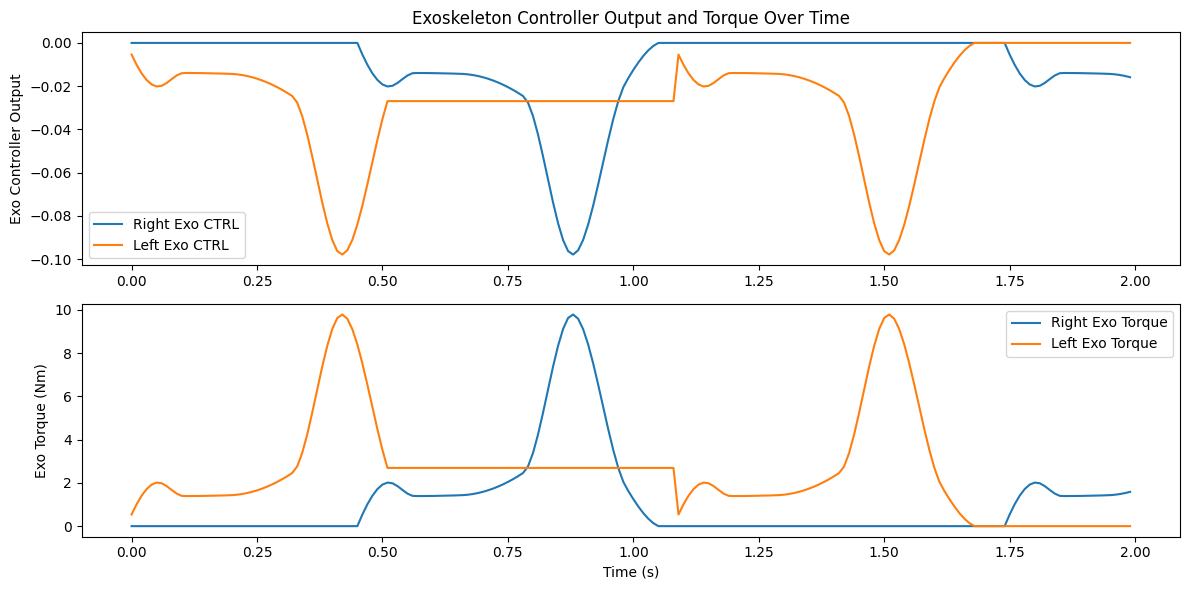

In [58]:
import matplotlib.pyplot as plt

exo_log = env.exo_data_log

times = [entry['time'] for entry in exo_log]
r_ctrl = [entry['r_ctrl'] for entry in exo_log]
l_ctrl = [entry['l_ctrl'] for entry in exo_log]
r_torque = [entry['r_torque'] for entry in exo_log]
l_torque = [entry['l_torque'] for entry in exo_log]

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(times, r_ctrl, label='Right Exo CTRL')
plt.plot(times, l_ctrl, label='Left Exo CTRL')
plt.ylabel('Exo Controller Output')
plt.legend()
plt.title('Exoskeleton Controller Output and Torque Over Time')

plt.subplot(2, 1, 2)
plt.plot(times, r_torque, label='Right Exo Torque')
plt.plot(times, l_torque, label='Left Exo Torque')
plt.xlabel('Time (s)')
plt.ylabel('Exo Torque (Nm)')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:

import skvideo.io
import numpy as np
import os

GENERATE_VIDEO = True
frames = []
video_out = r"C:\Users\rohan\Downloads\Exoskeleton_PD\Project Gallery\SetVideos\Legs\baseline\healthy.mp4"
os.makedirs("videos", exist_ok=True)

env.reset()

for i in range(200):
    reward, _, is_done = env.run_reflex_step_Cost()

    if GENERATE_VIDEO:
        if hasattr(env.env, "sim") and hasattr(env.env.sim, "renderer"):
            frame = env.env.sim.renderer.render_offscreen(width=400, height=400, camera_id=1)
        else:
            frame = env.env.render(mode="rgb_array")
        frames.append(np.array(frame))

    if is_done:
        break

if GENERATE_VIDEO and frames:
    skvideo.io.vwrite(video_out, np.asarray(frames), outputdict={'-pix_fmt': 'yuv420p'})
    print(f"Video saved to {video_out}")

Video saved to C:\Users\rohan\Downloads\Exoskeleton_PD\Project Gallery\SetVideos\Legs\baseline\healthy.mp4


In [8]:
print(env.muscle_labels)
print(env.muscles_dict)
print(env.muscle_Fmax)
print(env.muscle_L0)
print(env.muscle_LT)
print(env.torque_dict)

{'r_leg': {'GLU': ['glutmax_r'], 'HAM': ['hamstrings_r'], 'BFSH': ['bifemsh_r'], 'GAS': ['gastroc_r'], 'SOL': ['soleus_r'], 'HFL': ['iliopsoas_r'], 'RF': ['rectfem_r'], 'VAS': ['vasti_r'], 'TA': ['tibant_r'], 'FDL': ['fdl_r'], 'EDL': ['edl_r']}, 'l_leg': {'GLU': ['glutmax_l'], 'HAM': ['hamstrings_l'], 'BFSH': ['bifemsh_l'], 'GAS': ['gastroc_l'], 'SOL': ['soleus_l'], 'HFL': ['iliopsoas_l'], 'RF': ['rectfem_l'], 'VAS': ['vasti_l'], 'TA': ['tibant_l'], 'FDL': ['fdl_l'], 'EDL': ['edl_l']}}
{'r_leg': {'GLU': [4], 'HAM': [0], 'BFSH': [1], 'GAS': [8], 'SOL': [9], 'HFL': [5], 'RF': [6], 'VAS': [7], 'TA': [10], 'FDL': [3], 'EDL': [2]}, 'l_leg': {'GLU': [15], 'HAM': [11], 'BFSH': [12], 'GAS': [19], 'SOL': [20], 'HFL': [16], 'RF': [17], 'VAS': [18], 'TA': [21], 'FDL': [14], 'EDL': [13]}}
{'r_leg': {'GLU': array([3276.04]), 'HAM': array([3948.49]), 'BFSH': array([509.424]), 'GAS': array([3820.44]), 'SOL': array([6090.]), 'HFL': array([2585.58]), 'RF': array([1800.5]), 'VAS': array([9500.94]), 'TA'

In [2]:
# TEST MODEL ON ENVIRONMENT WITH 0 EXO ACTION BUT FATIGUE CAN BE CHOSEN || MAIN
import os
import numpy as np
from ctrl_optim.optim.optim_utils.fati_config_parser import load_params_and_create_testenv, print_config_summary

PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\dephy_0906_1958\myorfl_Kine_2D_1_25_2025Sep06_1958_None_BestLast.txt"
PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\dephy_0907_1648\myorfl_Kine_2D_1_25_2025Sep07_1648_None_BestLast.txt"

SIMULATION_TIME = 5
SLOPE_DEG = 0
MODEL = "dephy"        # Options: tutorial, dephy, hmedi, humotech, osl, baseline
EXO_BOOL = True
USE_4PARAM_SPLINE = False
N_POINTS = 4
MAX_TORQUE = 100

results_dir = os.path.dirname(PARAMS_FILE_PATH)
filename = os.path.basename(PARAMS_FILE_PATH)
bat_file_path = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\optim\training_configs\baseline_hmedi.bat"

env, config, _ = load_params_and_create_testenv(
    results_dir=results_dir,
    filename=filename,
    bat_file_path=bat_file_path,
    sim_time=SIMULATION_TIME
)

print_config_summary(config, title="Loaded Configuration")

fatigue_indices =  [5,6,16,17]
fatigue_range = (.1,.1)  

print(f"\n=== FATIGUE CONFIGURATION ===")
print(f"Fatigue indices: {fatigue_indices}")
print(f"Fatigue range: {fatigue_range} ({'No fatigue' if fatigue_range == (1.0, 1.0) or fatigue_range == (0.0, 0.0) else 'Fatigue enabled'})")
if fatigue_indices is None:
    print("Fatigue will be applied to ALL 22 muscles")
else:
    print(f"Fatigue will be applied to {len(fatigue_indices)} specific muscles: {fatigue_indices}")
# Wrap it with CumulativeFatigue-based scaling
env = ReflexExoWrapper(
    reflex_env=env,
    fatigue_indices=fatigue_indices,
    fatigue_range=fatigue_range,
    debug=True
)

from stable_baselines3 import PPO

model = PPO.load(r"ReflexExo_PPO_policy_dephy", env=env)

env.mj_render()
obs, info = env.reset()

print(f"Apply fatigue g: {env.apply_fatigue}")
print(f"MA : [{env._MA.min():.3f}, {env._MA.max():.3f}]")
print(f"MR : [{env._MR.min():.3f}, {env._MR.max():.3f}]")
print(f"MF : [{env._MF.min():.3f}, {env._MF.max():.3f}]")

if env.apply_fatigue:
    if fatigue_indices is None:
        print(f"Fatigue applied to ALL muscles")
        print(f"Initial MF values (all muscles): [{env._MF.min():.3f}, {env._MF.max():.3f}]")
    else:
        print(f"Fatigue applied to muscles: {fatigue_indices}")
        print(f"Initial MF values for selected muscles: {[f'{env._MF[idx]:.3f}' for idx in fatigue_indices]}")
else:
    print("NO FATIGUE")

import time
time.sleep(3)
tr = 0
for i in range(300):
    env.debug = False  # Turn off debug for cleaner output during loop
    env.mj_render()
    
    exo_actions = model.predict(obs, deterministic=True)
    exo_actions = exo_actions[0].flatten()
    exo_actions = [1,1]
    print("exo_actions:", exo_actions)
    if i % 10 == 0 and env.apply_fatigue:
        print(f"Step {i:3d} - CumulativeFatigue State:")
        print(f"  MA: [{env._MA.min():.3f}, {env._MA.max():.3f}] | MF: [{env._MF.min():.3f}, {env._MF.max():.3f}]")
        
        if fatigue_indices is None:
            # All muscles have fatigue applied
            print(f"  All muscles MF: [{env._MF.min():.3f}, {env._MF.max():.3f}]")
            strength_factors = 1.0 - env._MF
            print(f"  All muscles strength: [{strength_factors.min():.3f}, {strength_factors.max():.3f}]")
        else:
            # Only specific muscles have fatigue applied
            print(f"  Selected muscles MF: {[f'{env._MF[idx]:.3f}' for idx in fatigue_indices]}")
            strength_factors = [1.0 - env._MF[idx] for idx in fatigue_indices]
            print(f"  Selected muscles strength: {[f'{sf:.3f}' for sf in strength_factors]}")
    elif i % 10 == 0:
        print(f"Step {i:3d} - No fatigue applied (optimized path)")
    
    obs, reward, done, truncated, info = env.step(exo_actions)
    tr += reward
    
    if i % 10 == 0:  
        print(f"  Reward: {reward:.4f} | Total: {tr:.4f}")
    
    if done:
        print(f"Episode terminated at step {i}")
        break



if env.apply_fatigue:
    print(f"Final CumulativeFatigue state:")
    print(f"  MA (Muscle Active): [{env._MA.min():.3f}, {env._MA.max():.3f}]")
    print(f"  MR (Muscle Resting): [{env._MR.min():.3f}, {env._MR.max():.3f}]")
    print(f"  MF (Muscle Fatigue): [{env._MF.min():.3f}, {env._MF.max():.3f}]")
    
    if fatigue_indices is None:
        final_strength = 1.0 - env._MF
        print(final_strength)
    else:
        final_strength = [1.0 - env._MF[idx] for idx in fatigue_indices]
        print(final_strength)
else:
    print("No fati")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


MyoSuite:> Registering Myo Envs


c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoSarcArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoFatiArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoArmReachRandom-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registr

FileNotFoundError: Parameter file not found: C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\dephy_0907_1648\myorfl_Kine_2D_1_25_2025Sep07_1648_None_BestLast.txt

In [ ]:
# PPO Training for Reflex Exoskeleton Environment
import os
import numpy as np
from stable_baselines3 import PPO
from ctrl_optim.optim.optim_utils.fati_config_parser import load_params_and_create_testenv, print_config_summary


PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\dephy_0907_1648\myorfl_Kine_2D_1_25_2025Sep07_1648_None_BestLast.txt"
SIMULATION_TIME = 10

results_dir = os.path.dirname(PARAMS_FILE_PATH)
filename = os.path.basename(PARAMS_FILE_PATH)
bat_file_path = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\optim\training_configs\baseline_hmedi.bat"

env, config, _ = load_params_and_create_testenv(
    results_dir=results_dir,
    filename=filename,
    bat_file_path=bat_file_path,
    sim_time=SIMULATION_TIME
)

print_config_summary(config, title="Loaded Configuration")

fatigue_indices = [5, 6, 16, 17]
reflex_exo_env = ReflexExoWrapper(
    reflex_env=env,
    fatigue_indices=fatigue_indices,
    fatigue_range=(0.1, 0.1),
    debug=False
)

log_dir = "./ppo_reflex_exo_tensorboard/"

ppo_reflex_exo = PPO('MlpPolicy', reflex_exo_env, verbose=1, tensorboard_log=log_dir)

ppo_reflex_exo.learn(total_timesteps=500000)

ppo_reflex_exo.save('ReflexExo_PPO_policy_dephy')

print('Final policy saved as: ReflexExo_PPO_policy_dephy')
print('Total training timesteps: 1,000,000')

In [ ]:
# TEST MODEL ON ENVIRONMENT WITH 0 EXO ACTION BUT FATIGUE CAN BE CHOSEN || MAIN
import os
import numpy as np
from ctrl_optim.optim.optim_utils.fati_config_parser import load_params_and_create_testenv, print_config_summary

PARAMS_FILE_PATH = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\results\optim_results\dephy_0907_1648\myorfl_Kine_2D_1_25_2025Sep07_1648_None_BestLast.txt"

SIMULATION_TIME = 5
SLOPE_DEG = 0
MODEL = "dephy"        # Options: tutorial, dephy, hmedi, humotech, osl, baseline
EXO_BOOL = True
USE_4PARAM_SPLINE = False
N_POINTS = 4
MAX_TORQUE = 100

results_dir = os.path.dirname(PARAMS_FILE_PATH)
filename = os.path.basename(PARAMS_FILE_PATH)
bat_file_path = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_leg\myoassist\ctrl_optim\optim\training_configs\baseline_hmedi.bat"

env, config, _ = load_params_and_create_testenv(
    results_dir=results_dir,
    filename=filename,
    bat_file_path=bat_file_path,
    sim_time=SIMULATION_TIME
)

print_config_summary(config, title="Loaded Configuration")


import time
time.sleep(3)
tr = 0
for i in range(300):
    env.debug = False  
    env.mj_render()
    #Code doesn't work without MF, i have to find MF
    env.env.unwrapped.muscle_fatigue.MF[:] = MF
    env.run_reflex_step_Cost()


In [ ]:
import gymnasium as gym
import numpy as np

class FrozenReflexExoWrapper(gym.Env):

    def __init__(self, reflex_env, max_cost=1000):
        super().__init__()
        self.reflex_env = reflex_env
        self.max_cost = max_cost

        self.action_space = gym.spaces.Box(low=0, high=1.0, shape=(2,), dtype=np.float32)
        try:
            self.observation_space = reflex_env.env.observation_space
        except AttributeError:
            self.observation_space = reflex_env.observation_space

    def reset(self, **kwargs):
        obs, _ = self.reflex_env.reset_gym()
        return obs, {}

    def step(self, exo_actions):
        exo_actions = np.array(exo_actions, dtype=np.float32).flatten()
        if exo_actions.shape[0] != 2:
            raise ValueError(f"Expected 2 exoskeleton actions, got {exo_actions.shape[0]}")


        cost, _, done = self.reflex_env.run_reflex_step_Cost()
        reward = self.max_cost - cost

        try:
            obs = self.reflex_env.env._get_obs()
        except AttributeError:
            obs = self.reflex_env.env.unwrapped.get_obs()

        return obs, reward, done, False, {}

    def render(self, mode='human'):
        return self.reflex_env.env.mj_render()

    def close(self):
        self.reflex_env.close()